In [1]:
import os
#os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import sys

sys.path.insert(0, "/home/joshua/PhD_year_1/jaxsp/Adding_stellar_masses")

import jaxsp as jsp

import jax
jax.config.update("jax_enable_x64", True)
import numpy as np
import jax.numpy as jnp

import matplotlib.pyplot as plt

from jaxsp.constants import GN, hbar

import matplotlib.pyplot as plt

from collections import defaultdict


m22 = 1
u = jsp.set_schroedinger_units(m22)


JAX is not using 64-bit precision. This will dramatically affect numerical precision at even moderate L.


In [4]:



cNFWtides_params = jnp.array([
357964808.148399 * u.from_Msun,
25.690207,
0.407461,
0.012670 * u.from_Kpc,
1.857991 * u.from_Kpc,
3.729259
])

density_params = jsp.init_core_NFW_tides_params_from_sample(cNFWtides_params)

N = 512
rmin = .1 * u.from_pc
rmax = jsp.enclosing_radius(0.999, density_params)
potential_params = jsp.init_potential_params(density_params, rmin, rmax, N)

eval_library = jax.vmap(jax.vmap(jsp.eval_radial_eigenmode, in_axes=(None, 0)), in_axes=(0,None))

N = 1024
a = 1
b = 10

rmax = jsp.enclosing_radius(0.99, density_params)
eigenstate_lib = jsp.init_eigenstate_library(potential_params, rmin, rmax, a, b, N)


eigen_energies = eigenstate_lib.radial_eigenmode_params.E

l = eigenstate_lib.radial_eigenmode_params.l

n = eigenstate_lib.radial_eigenmode_params.n

rmin = 20 * u.from_pc

tol = 1e-7
wavefunction_params = jsp.init_wavefunction_params(eigenstate_lib, density_params, rmin, rmax, tol)

aj_2 = wavefunction_params.aj_2 



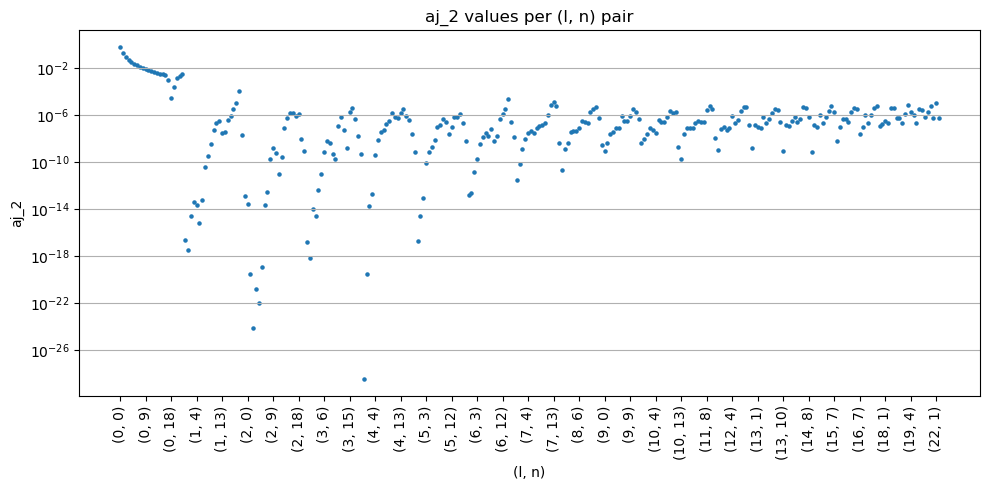

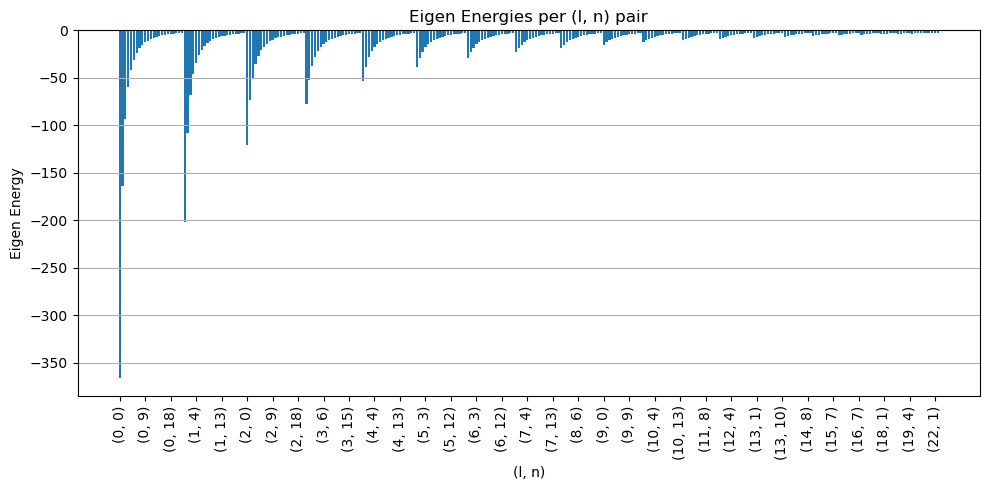

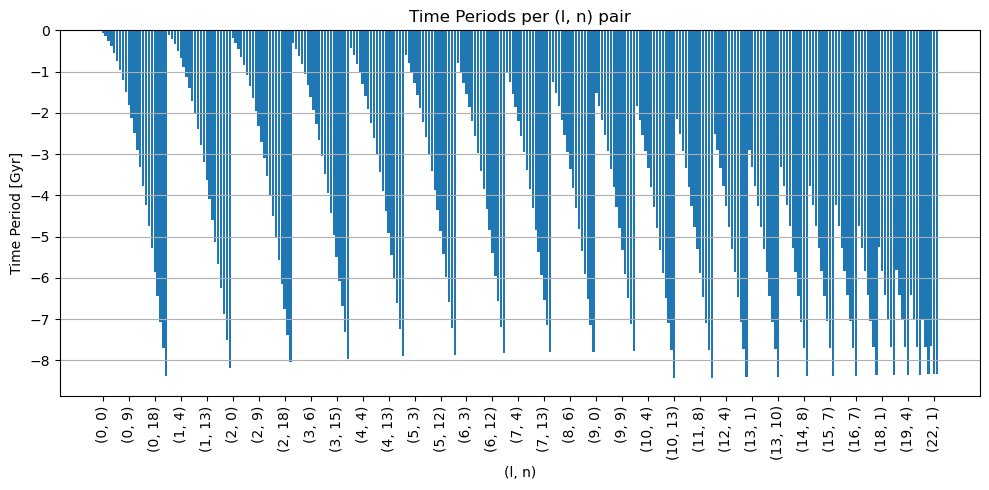

In [5]:

nl_labels = list(zip(l.tolist(), n.tolist()))


plt.figure(figsize=(10, 5))
plt.scatter(range(len(aj_2)), aj_2, s=5)

step = max(1, len(nl_labels) // 30)  # show ~30 labels
tick_positions = range(0, len(nl_labels), step)
tick_labels = [nl_labels[i] for i in tick_positions]
plt.xticks(tick_positions, tick_labels, rotation=90, fontsize=10)

plt.xlabel('(l, n)')
plt.ylabel('aj_2')
plt.title('aj_2 values per (l, n) pair')
plt.grid(axis='y')
plt.yscale('log')
plt.tight_layout()
plt.show()



plt.figure(figsize=(10, 5))
plt.bar(range(len(eigen_energies)), eigen_energies)

step = max(1, len(nl_labels) // 30)
tick_positions = range(0, len(nl_labels), step)
tick_labels = [nl_labels[i] for i in tick_positions]
plt.xticks(tick_positions, tick_labels, rotation=90, fontsize=10)

plt.xlabel('(l, n)')
plt.ylabel('Eigen Energy')
plt.title('Eigen Energies per (l, n) pair')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

time_periods = (1 / eigen_energies) * u.to_Gyr

plt.figure(figsize=(10, 5))
plt.bar(range(len(time_periods)), time_periods)

step = max(1, len(nl_labels) // 30)
tick_positions = range(0, len(nl_labels), step)
tick_labels = [nl_labels[i] for i in tick_positions]
plt.xticks(tick_positions, tick_labels, rotation=90, fontsize=10)

plt.xlabel('(l, n)')
plt.ylabel('Time Period [Gyr]')
plt.title('Time Periods per (l, n) pair')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


